In [13]:
# 1 - Load & Inspect Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Load dataset
df = sns.load_dataset('tips')

print('Shape:', df.shape)
print()

print(df.dtypes)
print()

print(df.head())
print()

print(df.describe().round(3))

Shape: (244, 7)

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

       total_bill      tip     size
count     244.000  244.000  244.000
mean       19.786    2.998    2.570
std         8.902    1.384    0.951
min         3.070    1.000    1.000
25%        13.348    2.000    2.000
50%        17.795    2.900    2.000
75%        24.127    3.562    3.000
max        50.810   10.000    6.000


In [14]:
# Cek Missing Value
print("\nJumlah Missing Value:")
print(df.isnull().sum())


Jumlah Missing Value:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


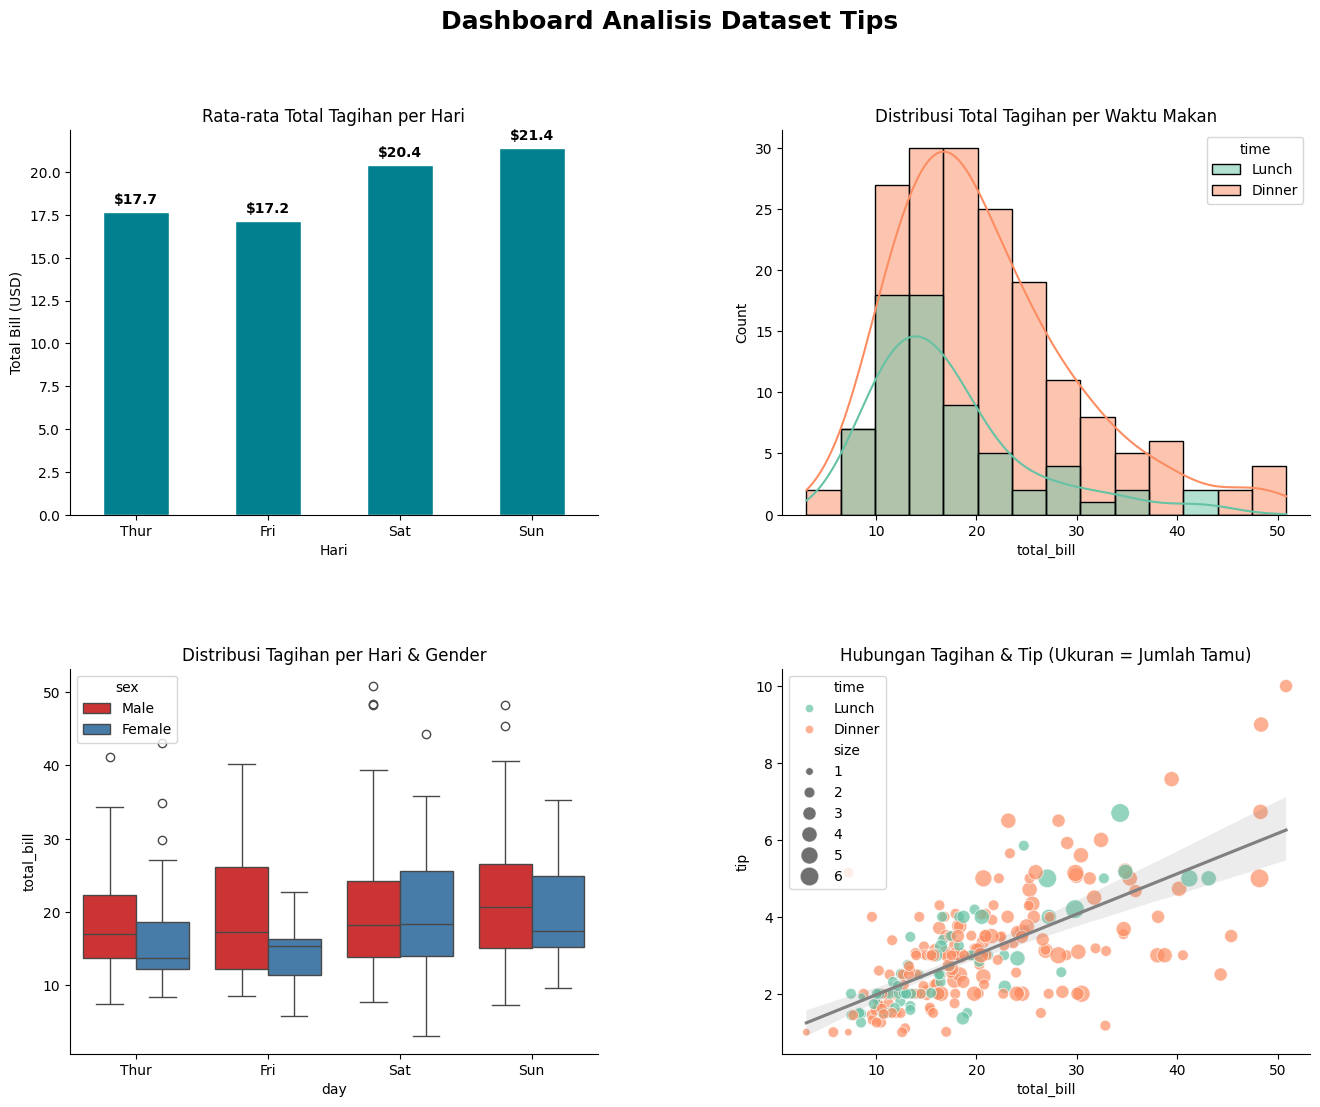

In [15]:
# 2 - Setup Figure Layout
fig = plt.figure(figsize=(16, 12))

fig.suptitle(
    'Dashboard Analisis Dataset Tips',
    fontsize=18,
    fontweight='bold',
    y=0.98
)

# Grid 2x2
gs = gridspec.GridSpec(
    2, 2,
    figure=fig,
    hspace=0.4,
    wspace=0.35
)

# Subplot
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# 3. Grafik 1 - Bar Chart
avg_by_day = df.groupby('day', observed=False)['total_bill'].mean()

avg_by_day.plot(
    kind='bar',
    ax=ax1,
    color='#028090',
    edgecolor='white'
)

# Tambahkan label nilai di atas tiap bar
for bar, val in zip(ax1.patches, avg_by_day.values):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'${val:.1f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari')
ax1.set_ylabel('Total Bill (USD)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top', 'right']].set_visible(False)

# Grafik 2 - Histogram + KDE
sns.histplot(
    data=df,
    x='total_bill',
    hue='time',
    kde=True,
    palette='Set2',
    ax=ax2
)

ax2.set_title('Distribusi Total Tagihan per Waktu Makan')

ax2.spines[['top', 'right']].set_visible(False)

# Grafik 3 - Boxplot
sns.boxplot(
    data=df,
    x='day',
    y='total_bill',
    hue='sex',
    palette='Set1',
    ax=ax3
)

ax3.set_title('Distribusi Tagihan per Hari & Gender')

ax3.spines[['top', 'right']].set_visible(False)

# 6. Grafik 4 - Scatter Plot
sns.scatterplot(
    data=df,
    x='total_bill',
    y='tip',
    hue='time',
    size='size',
    sizes=(30, 180),
    palette='Set2',
    alpha=0.7,
    ax=ax4
)

sns.regplot(
    data=df,
    x='total_bill',
    y='tip',
    scatter=False,
    color='gray',
    ax=ax4
)

ax4.set_title('Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)')

ax4.spines[['top', 'right']].set_visible(False)



**ANALISIS SETIAP GRAFIK - DATASET TIPS**

Grafik 1 - Bar Chart (Rata-rata Total Tagihan per Hari)
*   **What** : Grafik menunjukkan bahwa hari Minggu memiliki rata-rata total bill tertinggi sekitar 21,4 USD, sedangkan Jumat memiliki rata-rata terendah sekitar 17,2 USD.
*   **So What** : Hal ini menunjukkan bahwa pelanggan cenderung melakukan transaksi lebih besar pada akhir pekan. Kemungkinan jumlah pengunjung dan aktivitas makan bersama keluarga lebih tinggi pada hari Minggu.
*   **Now What** : Restoran dapat meningkatkan jumlah staf dan persediaan makanan pada akhir pekan untuk mengantisipasi kenaikan transaksi.

Grafik 2 - Histogram + KDE (Distribusi Total Tagihan per Waktu Makan)
*   **What** : Histogram menunjukkan distribusi total tagihan pelanggan berdasarkan waktu makan, yaitu Lunch dan Dinner. Sebagian besar transaksi Lunch dan Dinner berada pada rentang 10–20 USD. Namun, Dinner memiliki lebih banyak transaksi dan nilai tagihan lebih tinggi hingga mendekati 50 USD.
*   **So What** : Hal ini menunjukkan pelanggan saat Dinner cenderung mengeluarkan uang lebih banyak dibanding Lunch. Variasi tagihan Dinner juga lebih besar.
*   **Now What** : Restoran dapat memfokuskan strategi penjualan menu premium atau paket keluarga pada waktu Dinner karena potensi transaksi lebih besar. Analisis lanjutan dapat dilakukan untuk mengetahui apakah ukuran grup pelanggan saat Dinner menjadi faktor utama meningkatnya total bill.

Grafik 3 - Boxplot (Distribusi Tagihan per Hari & Gender)
*   **What** : Grafik menunjukkan median total tagihan pelanggan laki-laki lebih tinggi dibanding perempuan pada hampir semua hari. Selain itu, terdapat beberapa outlier transaksi tinggi di atas 40 USD terutama pada hari Sabtu dan Minggu.
*   **So What** : Hal ini menunjukkan pelanggan pada akhir pekan cenderung melakukan transaksi lebih besar. Variasi tagihan juga lebih tinggi terutama pada pelanggan laki-laki.
*   **Now What** : Restoran dapat meningkatkan pelayanan dan promosi pada akhir pekan. Analisis selanjutnya dapat melihat apakah jumlah pelanggan mempengaruhi besarnya tagihan.

Grafik 4 - Scatter Plot (Hubungan Tagihan & Tip)
*   **What** : Grafik menunjukkan hubungan positif antara total tagihan dan tip. Semakin besar total tagihan pelanggan maka semakin besar tip yang diberikan. beberapa transaksi besar memiliki tip hingga 10 USD.
*   **So What** : Hal ini menunjukkan nilai tip dipengaruhi oleh besarnya transaksi pelanggan.
*   **Now What** : Restoran dapat meningkatkan penjualan menu agar total tagihan meningkat. Analisis berikutnya dapat melihat apakah jumlah tamu mempengaruhi besar tip pelanggan.


